In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


# **Importing libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Loading the dataset**

In [3]:
df_train = pd.read_csv('../input/titanic/train.csv')
df_test = pd.read_csv('../input/titanic/test.csv')

# **Exploratory Data Analysis**

In [4]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df_train.shape

(891, 12)

**The dataset has 891 records and 12 attributes.**

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


**The dataset has 2 float, 5 integer and 5 object columns.**

### **Attribute Description:-**
1. PassengerId: stores passenger's id
2. Survived: tells whether the passenger survived or not. 0 indicates No and 1 indicates Yes.
3. Pclass: A proxy for socio-economic status (SES) where 1 is Upper, 2 is Middle and 3 is Lower class.
4. Name: contains the name of passenger
5. Sex: stores the gender of passenger
6. Age: stores the age of passenger
7. Sibsp: stores the number of siblings or spouse aboard of each passenger
8. Parch: stores the number of parents or children aboard of each passenger
9. Ticket: stores the ticket number
10. Fare: contains the ticket fare
11. Cabin: stores the cabin number in which the passenger stayed
12. Embarked: stores the port of embarkation. C is Cherbourg, Q is Queenston, S is Southampton

In [7]:
df_train.corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [8]:
# Check for duplicates

duplicate = df_train[df_train.duplicated()]
duplicate

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


**The dataset doesn't have any duplicate records.**

In [9]:
# Check for missing values

df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**Observations:-**
* Maximum unkown records are present in Cabin column, so it's best to drop that column.
* Missing values in Age column can be replaced by mean or median.
* There are 2 missing values in Embarked column.

In [10]:
# Replace missing values in Age column with median age

# We will groupby Pclass to find the median age of passenger in each class

df_train.groupby('Pclass')['Age'].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

**Observations:-**
* Median Age of passengers in class 1 is 37.
* Median Age of passengers in class 2 is 29.
* Median Age of passengers in class 3 is 24.

In [11]:
# Replace with median age of each class

df_train['Age'] = np.where(df_train['Pclass']==1, 37, df_train['Age'])
df_train['Age'] = np.where(df_train['Pclass']==2, 29, df_train['Age'])
df_train['Age'] = np.where(df_train['Pclass']==3, 24, df_train['Age'])

In [12]:
# Drop Cabin column

df_train.drop(['Cabin'], axis=1, inplace=True)

In [13]:
# Remove remaining rows having missing values

df_train.dropna(inplace=True)

In [14]:
# Check for null values again

df_train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Hence, all missing values are removed from training set.**

In [15]:
# Missing values in test set

df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [16]:
# Replace with median age of each class

df_test['Age'] = np.where(df_test['Pclass']==1, 37, df_test['Age'])
df_test['Age'] = np.where(df_test['Pclass']==2, 29, df_test['Age'])
df_test['Age'] = np.where(df_test['Pclass']==3, 24, df_test['Age'])

In [17]:
# Replace fare with median

df_test[df_test['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,24.0,0,0,3701,NaN,NaN,S


In [18]:
# We will groupby Pclass to find the median age of passenger in each class

df_train.groupby('Pclass')['Fare'].median()

Pclass
1    58.6896
2    14.2500
3     8.0500
Name: Fare, dtype: float64

In [19]:
df_test['Fare'].fillna(14.25, inplace=True)

In [20]:
# Drop Cabin column

df_test.drop('Cabin', axis=1, inplace=True)

In [21]:
df_test.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

**Hence, all missing values are removed from training set.**

## **Visualizations**

In [22]:
corr = df_train.corr()
corr.style.background_gradient(cmap='Purples').set_precision(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,-0.04,0.04,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.34,0.33,-0.03,0.08,0.26
Pclass,-0.04,-0.34,1.00,-0.99,0.08,0.02,-0.55
Age,0.04,0.33,-0.99,1.00,-0.08,-0.02,0.57
SibSp,-0.06,-0.03,0.08,-0.08,1.00,0.41,0.16
Parch,-0.00,0.08,0.02,-0.02,0.41,1.00,0.22
Fare,0.01,0.26,-0.55,0.57,0.16,0.22,1.00


**Observations:-**
* There is a positive correlation of 0.57 between Age and Fare. It indicates that older passengers were charged more than younger passengers.
* There is a negative correlation of 0.55 between Pclass and Fare. It menas that upper class passengers(Pclass=1) had high fare followed by middle class(Pclass=2) and lower class(Pclass=3).

<AxesSubplot:xlabel='Survived', ylabel='count'>

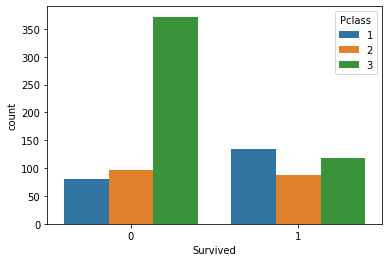

In [23]:
# Number of passengers survived in each class

sns.countplot(data=df_train, x='Survived', hue='Pclass')

**Observations:-**
* Maximum passengers(nearly 150) who survived were from upper class.
* Nearly 100 passengers survived from lower class followed by middle class.
* More than 350 passengers who died where from lower class.
* Least passengers who died were from upper class followed by middle class.

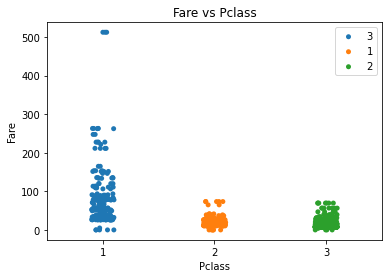

In [24]:
# Fare distribution of each class

sns.stripplot(x="Pclass", y="Fare", data=df_train)
plt.legend(df_train.Pclass.value_counts().index)
plt.title("Fare vs Pclass")
plt.show()

**Observations:-**
* Fare for upper class is between 0 to nearly 300 dollars. There are some records for which the fare is above 500 dollars.
* For middle class and lower class the fare is between 0 to 100 dollars.

<AxesSubplot:xlabel='Embarked', ylabel='count'>

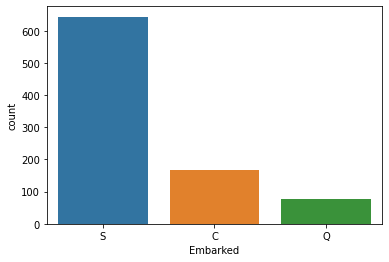

In [25]:
# Plot of Embarked

sns.countplot(data=df_train, x='Embarked')

**Observations:-**
* Maximum passengers(greater than 600) boarded from Southampton.
* More than 150 passengers boarded from Cherbourg.
* Less than 100 passengers boarded from Queenston.

<AxesSubplot:xlabel='Survived', ylabel='count'>

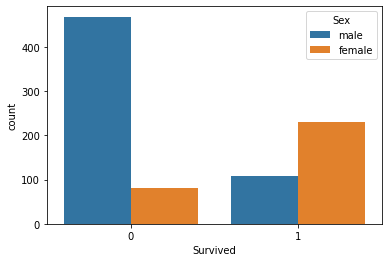

In [26]:
# Male and female passengers who survived

sns.countplot(data=df_train, x='Survived', hue='Sex')

**Observations:-**
* More than 200 female passengers and more than 100 male passengers survived.
* More than 400 male passengers and less than 100 female passengers died.

<AxesSubplot:xlabel='Age', ylabel='Density'>

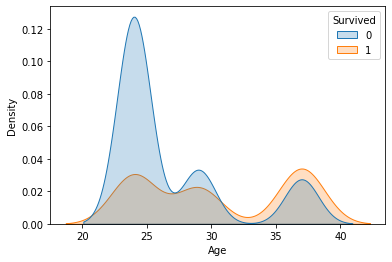

In [27]:
sns.kdeplot(x='Age', hue='Survived', data=df_train, fill=True)

**Observations:-**
* Most of the passengers who survived were 35 to 40 years old.
* Followed by the age 22 to 27.

In [28]:
# Drop columns in train and test data

col_train=['PassengerId', 'Name', 'Ticket']
df_train.drop(col_train, axis=1, inplace=True)

col_test=['Name', 'Ticket']
df_test.drop(col_test, axis=1, inplace=True)

In [29]:
df_train.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [30]:
df_test.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [31]:
# Encoding categorical variables

# for encoding
from sklearn.preprocessing import LabelEncoder

def label_encoding(feature):
    le = LabelEncoder()
    le.fit(feature)
    print(feature.name, le.classes_)
    return le.transform(feature)

In [32]:
# Train data
cols = ['Sex', 'Embarked']
for col in cols:
    df_train[col] = label_encoding(df_train[col])

Sex ['female' 'male']
Embarked ['C' 'Q' 'S']


In [33]:
# Test data
for col in cols:
    df_test[col] = label_encoding(df_test[col])

Sex ['female' 'male']
Embarked ['C' 'Q' 'S']


# **Model**

In [34]:
# Separate independent and dependent variables

X_train = df_train.drop(['Survived'], axis=1, inplace=False)
y_train = df_train['Survived']

X_test = df_test.drop(['PassengerId'], axis=1, inplace=False)

### **1. Decision Tree Classifier**

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [36]:
y_pred_dt = dt.predict(X_test)
y_pred_dt

array([0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [37]:
output = pd.DataFrame({'PassengerId': df_test.PassengerId, 'Survived': y_pred_dt})
output.to_csv('my_submission.csv', index=False)
print("Your submission was successfully saved!")

Your submission was successfully saved!
